# Day 3: Multi-Class Classification
## The Journey to MNIST and Softmax Probabilities
---
**Objective:** Build a model that can recognize handwritten digits (0-9). 

### Why is today different?
1. **Input Shape**: We are moving from 2 numbers (x1, x2) to 784 pixels (28x28 images).
2. **Output Shape**: We need 10 output neurons (one for each digit).
3. **Probability**: We use Softmax to make the model pick the 'most likely' digit.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Load the MNIST Dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

print(f"Total training images: {len(train_set)}")

Total training images: 60000


### 3.1 Understanding the Data Shape
In PyTorch, images are usually `[Batch, Channels, Height, Width]`. Let's inspect one batch.

Batch Image Shape: torch.Size([64, 1, 28, 28])
Label Shape: torch.Size([64])


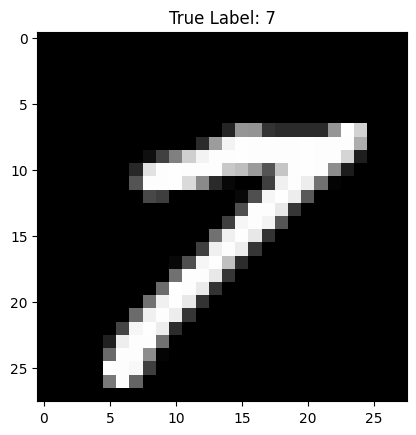

In [2]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Batch Image Shape: {images.shape}") # Should be [64, 1, 28, 28]
print(f"Label Shape: {labels.shape}")        # Should be [64]

plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f"True Label: {labels[0].item()}")
plt.show()

### 3.2 The Softmax Math
A model outputs 'Logits' (raw scores). Softmax turns them into probabilities that sum to 1.
$$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} $$

**PyTorch Tip:** `nn.CrossEntropyLoss()` combines `LogSoftmax` and `NLLLoss` into one. This means your model's last layer should just be a `Linear` layer without an activation!

In [3]:
class MNIST_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # We flatten 28x28 into 784
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.hidden2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        return self.output(x) # Raw scores (Logits)

model = MNIST_MLP()
print(model)

MNIST_MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
)


### 3.3 Training Loop with Evaluation
We will now track both **Loss** and **Accuracy** during training.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

for epoch in range(3):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, lbls in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate Accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += lbls.size(0)
        correct += (predicted == lbls).sum().item()
        
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")

Epoch 1 | Loss: 0.3385 | Acc: 89.37%
Epoch 2 | Loss: 0.1734 | Acc: 94.59%
Epoch 3 | Loss: 0.1373 | Acc: 95.78%


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         5
           2       1.00      0.86      0.92         7
           3       1.00      1.00      1.00         4
           4       1.00      0.83      0.91         6
           5       1.00      0.89      0.94         9
           6       0.71      1.00      0.83         5
           7       0.80      1.00      0.89         4
           8       1.00      1.00      1.00         5
           9       0.89      0.89      0.89         9

    accuracy                           0.94        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.94      0.94        64



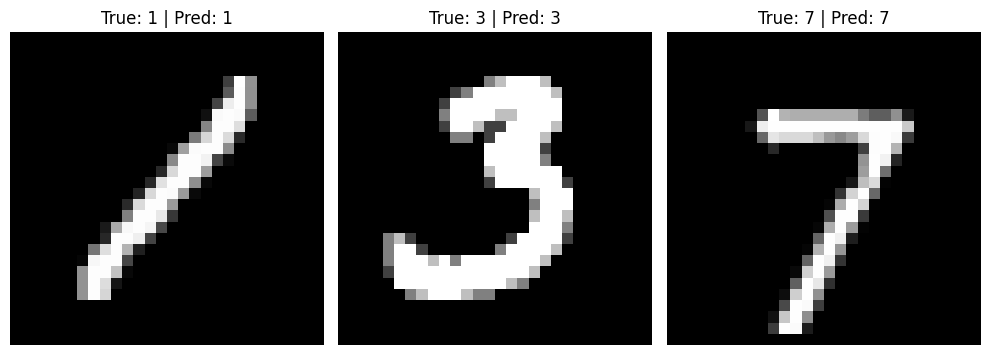

In [6]:
from sklearn.metrics import classification_report
import numpy as np
import random
model.eval()
# Get a batch from train_loader for evaluation
dataiter = iter(train_loader)
images, labels = next(dataiter)
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    y_true = labels.numpy()
    y_pred = predicted.numpy()
print("Classification Report:\n", classification_report(y_true, y_pred))
# Show 2-3 predictions with images
plt.figure(figsize=(10,4))
for i in range(3):
    idx = random.randint(0, len(images)-1)
    img = images[idx].numpy().squeeze()
    true_label = labels[idx].item()
    pred_label = predicted[idx].item()
    plt.subplot(1,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()